# ReAct Agent with LangGraph — OpenAI Primary and Groq Fallback

This notebook implements an end-to-end ReAct agent using:

- LangGraph `StateGraph`
- OpenAI as the primary LLM
- Groq as the fallback LLM
- Tool calling
- `ToolNode`
- Conditional routing
- Agent → Tool → Agent loop
- Optional conversation memory


## Cell 1: Install Libraries

In [2]:
# %pip install -U langgraph langchain langchain-openai langchain-groq python-dotenv

## Cell 2: Imports

In [1]:
import ast
import operator
import os
from typing import Annotated

from dotenv import load_dotenv
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


## Cell 3: Environment Variables

Create a `.env` file:

```text
OPENAI_API_KEY=your_openai_api_key
GROQ_API_KEY=your_groq_api_key
```


In [2]:
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY1")
groq_api_key = os.getenv("GROQ_API_KEY_S")

if not openai_api_key and not groq_api_key:
    raise ValueError(
        "Add OPENAI_API_KEY or GROQ_API_KEY to the .env file."
    )

print("OpenAI configured:", bool(openai_api_key))
print("Groq configured:", bool(groq_api_key))


OpenAI configured: False
Groq configured: True


## Cell 4: Initialize Primary and Fallback Models

In [3]:
primary_llm = None
fallback_llm = None

if openai_api_key:
    primary_llm = ChatOpenAI(
        model="gpt-4.1-mini",
        temperature=0,
        api_key=openai_api_key,
        max_retries=1,
        timeout=30,
    )

if groq_api_key:
    fallback_llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0,
        api_key=groq_api_key,
        max_retries=1,
        timeout=30,
    )


## Cell 5: Weather Tool

In [4]:
@tool
def get_weather(city: str) -> str:
    """Get simulated weather information for a city."""

    weather_database = {
        "delhi": {
            "temperature": 34,
            "condition": "Rainy",
            "rain_probability": 80,
        },
        "jaipur": {
            "temperature": 36,
            "condition": "Sunny",
            "rain_probability": 10,
        },
        "mumbai": {
            "temperature": 29,
            "condition": "Cloudy",
            "rain_probability": 65,
        },
        "bengaluru": {
            "temperature": 25,
            "condition": "Cloudy",
            "rain_probability": 40,
        },
    }

    city_key = city.strip().lower()
    weather = weather_database.get(city_key)

    if weather is None:
        return f"Weather information is not available for {city}."

    return (
        f"Weather in {city.title()}: "
        f"{weather['temperature']}°C, "
        f"{weather['condition']}, "
        f"rain probability {weather['rain_probability']}%."
    )


## Cell 6: Safe Calculator Tool

In [5]:
ALLOWED_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.Mod: operator.mod,
    ast.USub: operator.neg,
    ast.UAdd: operator.pos,
}


def evaluate_expression(node):
    if isinstance(node, ast.Expression):
        return evaluate_expression(node.body)

    if isinstance(node, ast.Constant):
        if isinstance(node.value, (int, float)):
            return node.value
        raise ValueError("Only numeric constants are allowed.")

    if isinstance(node, ast.BinOp):
        operation = ALLOWED_OPERATORS.get(type(node.op))
        if operation is None:
            raise ValueError("Unsupported operator.")

        return operation(
            evaluate_expression(node.left),
            evaluate_expression(node.right),
        )

    if isinstance(node, ast.UnaryOp):
        operation = ALLOWED_OPERATORS.get(type(node.op))
        if operation is None:
            raise ValueError("Unsupported unary operator.")

        return operation(evaluate_expression(node.operand))

    raise ValueError("Unsupported expression.")


@tool
def calculator(expression: str) -> str:
    """Calculate a restricted mathematical expression."""

    try:
        parsed = ast.parse(expression, mode="eval")
        result = evaluate_expression(parsed)
        return f"The result of {expression} is {result}."

    except ZeroDivisionError:
        return "Calculation failed: division by zero."

    except (SyntaxError, ValueError, TypeError) as error:
        return f"Calculation failed: {error}"


## Cell 7: Order Status Tool

In [6]:
@tool
def get_order_status(order_id: str) -> str:
    """Retrieve the simulated status of an order."""

    order_database = {
        "ORD101": {
            "status": "Delayed",
            "expected_delivery": "5 August 2026",
        },
        "ORD102": {
            "status": "Delivered",
            "expected_delivery": "1 August 2026",
        },
        "ORD103": {
            "status": "Processing",
            "expected_delivery": "7 August 2026",
        },
    }

    normalized_order_id = order_id.strip().upper()
    order = order_database.get(normalized_order_id)

    if order is None:
        return f"No order was found with ID {normalized_order_id}."

    return (
        f"Order {normalized_order_id} is {order['status']}. "
        f"Expected delivery: {order['expected_delivery']}."
    )


## Cell 8: Tool List and Tool Binding

In [7]:
tools = [
    get_weather,
    calculator,
    get_order_status,
]

primary_llm_with_tools = (
    primary_llm.bind_tools(tools)
    if primary_llm is not None
    else None
)

fallback_llm_with_tools = (
    fallback_llm.bind_tools(tools)
    if fallback_llm is not None
    else None
)


## Cell 9: Agent State

In [8]:
class AgentState(TypedDict):
    messages: Annotated[
        list[AnyMessage],
        add_messages,
    ]


## Cell 10: System Prompt

In [9]:
SYSTEM_PROMPT = """
You are a helpful ReAct AI agent.

You have access to:
1. Weather lookup
2. Mathematical calculation
3. Order-status lookup

Instructions:
- Use a tool when external information or exact calculation is required.
- Answer directly when no tool is required.
- Do not invent tool results.
- Use tool observations to prepare the final answer.
- If a tool fails, explain the problem clearly.
- Keep the final answer concise.
"""


## Cell 11: OpenAI → Groq Fallback Logic

In [10]:
def invoke_model_with_fallback(messages):
    primary_error = None

    if primary_llm_with_tools is not None:
        try:
            response = primary_llm_with_tools.invoke(messages)
            print("Model provider used: OpenAI")
            return response

        except Exception as error:
            primary_error = error
            print(
                "OpenAI invocation failed. "
                "Switching to Groq fallback."
            )
            print(
                f"OpenAI error: {type(error).__name__}: {error}"
            )

    if fallback_llm_with_tools is not None:
        try:
            response = fallback_llm_with_tools.invoke(messages)
            print("Model provider used: Groq")
            return response

        except Exception as fallback_error:
            raise RuntimeError(
                "Both model providers failed. "
                f"OpenAI error: {primary_error}. "
                f"Groq error: {fallback_error}."
            ) from fallback_error

    if primary_error is not None:
        raise RuntimeError(
            "OpenAI failed and Groq fallback is not configured."
        ) from primary_error

    raise RuntimeError("No model provider is configured.")


## Cell 12: Agent Node

In [11]:
def agent_node(state: AgentState) -> dict:
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *state["messages"],
    ]

    response = invoke_model_with_fallback(messages)

    return {
        "messages": [response]
    }


## Cell 13: Tool Node

In [12]:
tool_node = ToolNode(
    tools=tools,
    handle_tool_errors=True,
)


## Cell 14: Build the ReAct Graph

In [13]:
builder = StateGraph(AgentState)

builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
)

builder.add_edge("tools", "agent")

graph = builder.compile()



The execution flow is:

```text
START
  ↓
agent
  ↓
Tool call exists?
  ├── Yes → tools → agent
  └── No  → END
```


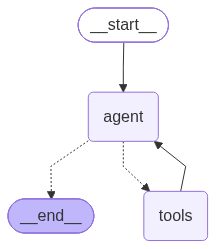

In [14]:
# ==========================================================
# Cell 6 : Visualize the LangGraph Workflow
# ==========================================================

from IPython.display import Image, display

# Display the graph
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

## Cell 15: Direct Answer Test

In [15]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="What is an AI agent?")
    ]
})

print(result["messages"][-1].content)


Model provider used: Groq
An AI (Artificial Intelligence) agent is a computer program that uses artificial intelligence to perform tasks, make decisions, and interact with its environment. It is designed to perceive its environment, reason about the current state, and take actions to achieve its goals. AI agents can be simple or complex, and they can be used in various applications, such as virtual assistants, chatbots, and expert systems.


## Cell 16: Weather Tool Test

In [16]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "What is the weather in Delhi, "
                "and should I carry an umbrella?"
            )
        )
    ]
})

print(result["messages"][-1].content)


Model provider used: Groq
Model provider used: Groq
It is raining in Delhi with a high probability of 80%. Yes, you should carry an umbrella.


## Cell 17: Calculator Tool Test

In [17]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="Calculate the average of 32, 34 and 33."
        )
    ]
})

print(result["messages"][-1].content)


Model provider used: Groq
Model provider used: Groq
The average of 32, 34, and 33 is 33.0.


## Cell 18: Order Status Test

In [18]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="What is the status of order ORD101?"
        )
    ]
})

print(result["messages"][-1].content)


Model provider used: Groq
Model provider used: Groq
The status of order ORD101 is Delayed, with an expected delivery date of 5 August 2026.


## Cell 19: Multiple Tool Calls

In [19]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "Check the weather in Delhi and Jaipur. "
                "Also calculate their average temperature."
            )
        )
    ]
})

print(result["messages"][-1].content)


Model provider used: Groq
Model provider used: Groq
Model provider used: Groq
The weather in Delhi is 34°C with an 80% chance of rain, and in Jaipur, it's 36°C with a 10% chance of rain. The average temperature between Delhi and Jaipur is 35°C.


## Cell 20: Inspect Full Message History

In [20]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "Check order ORD101 and calculate "
                "how many days remain until 5 August "
                "if today is 3 August."
            )
        )
    ]
})

for index, message in enumerate(result["messages"], start=1):
    print("=" * 70)
    print(f"Message {index}")
    print(f"Type: {type(message).__name__}")

    if getattr(message, "content", None):
        print(f"Content: {message.content}")

    if getattr(message, "tool_calls", None):
        print(f"Tool calls: {message.tool_calls}")


Model provider used: Groq
Model provider used: Groq
Message 1
Type: HumanMessage
Content: Check order ORD101 and calculate how many days remain until 5 August if today is 3 August.
Message 2
Type: AIMessage
Tool calls: [{'name': 'get_order_status', 'args': {'order_id': 'ORD101'}, 'id': 'vsbepqr2v', 'type': 'tool_call'}, {'name': 'calculator', 'args': {'expression': '5 - 3'}, 'id': 'r9zh588q5', 'type': 'tool_call'}]
Message 3
Type: ToolMessage
Content: Order ORD101 is Delayed. Expected delivery: 5 August 2026.
Message 4
Type: ToolMessage
Content: The result of 5 - 3 is 2.
Message 5
Type: AIMessage
Content: The order status for ORD101 is Delayed, with an expected delivery of 5 August 2026. There are 2 days remaining until 5 August.


## Cell 21: Stream Graph Updates

In [21]:
user_input = {
    "messages": [
        HumanMessage(
            content=(
                "What is the weather in Mumbai, "
                "and should I carry an umbrella?"
            )
        )
    ]
}

for event in graph.stream(
    user_input,
    stream_mode="updates",
):
    print(event)
    print("-" * 70)


Model provider used: Groq
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7gbbjcpfs', 'function': {'arguments': '{"city":"Mumbai"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 421, 'total_tokens': 436, 'completion_time': 0.037387781, 'completion_tokens_details': None, 'prompt_time': 0.020712284, 'prompt_tokens_details': None, 'queue_time': 0.160929096, 'total_time': 0.058100065}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc5fb-871b-75b3-8bd1-e4990b42d51f-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Mumbai'}, 'id': '7gbbjcpfs', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 421, 'output_tokens': 15, 'total_tokens': 436})]}}
----------------------------------------------

## Cell 22: Add Conversation Memory

#### In LangGraph, a checkpointer saves the graph state after each step.
State        = current workflow data

Checkpointer = saves and reloads that state

thread_id    = identifies one conversation
#### Note : InMemorySaver stores data temporarily in RAM. For production, use a database-backed checkpointer so memory remains after the application restarts.

In [22]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

graph_with_memory = builder.compile(
    checkpointer=checkpointer
)

config = {
    "configurable": {
        "thread_id": "react-agent-user-101"
    }
}


## Cell 23: First Conversation Turn

In [23]:
result = graph_with_memory.invoke(
    {
        "messages": [
            HumanMessage(
                content="Check the weather in Jaipur."
            )
        ]
    },
    config=config,
)

print(result["messages"][-1].content)


Model provider used: Groq
Model provider used: Groq
The current weather in Jaipur is 36°C, sunny with a 10% chance of rain.


## Cell 24: Second Conversation Turn

In [24]:
result = graph_with_memory.invoke(
    {
        "messages": [
            HumanMessage(
                content="What was the temperature in that city?"
            )
        ]
    },
    config=config,
)

print(result["messages"][-1].content)


Model provider used: Groq
The temperature in Jaipur was 36°C.


## Cell 25: Force Groq Fallback Test

In [25]:
saved_primary_model = primary_llm_with_tools

try:
    primary_llm_with_tools = None

    fallback_result = graph.invoke({
        "messages": [
            HumanMessage(
                content="What is the weather in Delhi?"
            )
        ]
    })

    print(fallback_result["messages"][-1].content)

finally:
    primary_llm_with_tools = saved_primary_model


Model provider used: Groq
Model provider used: Groq
The weather in Delhi is 34°C, rainy, with an 80% chance of rain.


# Step-by-Step Logic

1. The user message enters `AgentState`.
2. The agent node adds the system prompt.
3. The application calls OpenAI first.
4. When OpenAI fails, the application sends the same messages and tool schemas to Groq.
5. The selected model decides whether a tool is required.
6. `tools_condition` checks the latest AI response.
7. If a tool call exists, `ToolNode` executes the tool.
8. The tool result is added as a `ToolMessage`.
9. The graph returns to the agent node.
10. The model may call another tool or produce a final answer.
11. The graph ends when the AI response contains no tool call.
